- https://mp.weixin.qq.com/s/5GrgIC_k5jBetLcaUoCDMQ

本文目录：
1. 先搞清楚：大模型 RL 到底在训什么
2. RL 的时间为什么耗在推理侧
3. FSDP Turbo 如何压长序列成本
4. 异步 Flow 怎样消灭等待
5. 投机推理如何缩短单样本 Decode
6. 训推一致性为什么是最后一关

In [1]:
from IPython.display import Image

RL 训练循环与训推不一致的根源：Rollout → Reward → Training，一致性决定了整个回路是否可信。

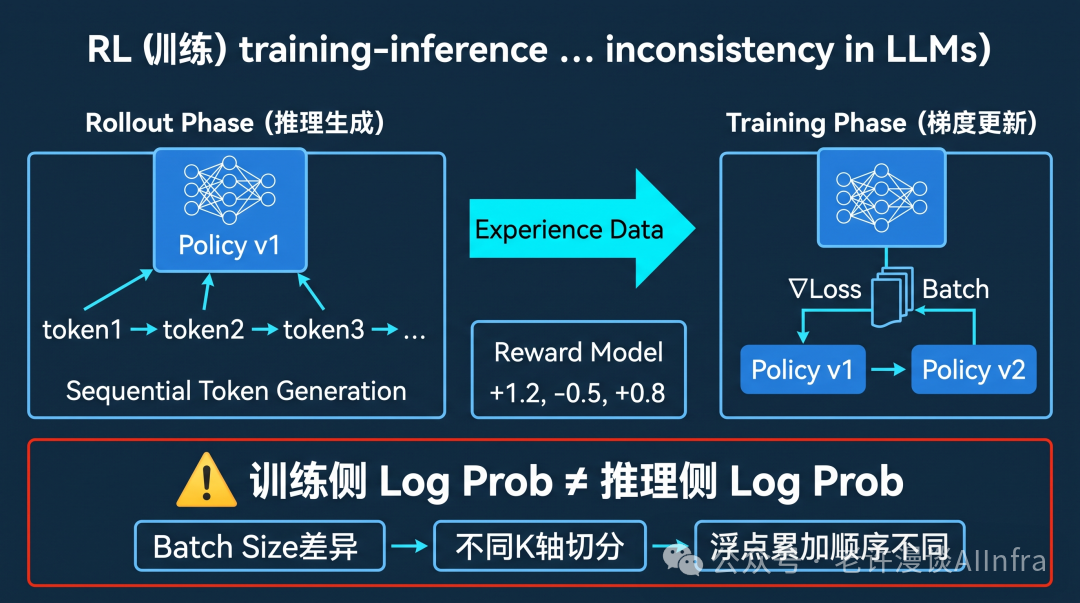

In [2]:
Image(filename='./Image/rl_01.png')



训练侧的 Reward 曲线在上涨，推理侧的 Log Prob 却和训练对不上。更麻烦的是，两个实现都"能跑"，Loss 也没有立刻爆炸。差异可能来自一次 Hadamard 变换、一个 SwiGLU 融合算子，或者 Batch Size 变化后不同的 MatMul 累加顺序。在强化学习系统里，性能和正确性不是两条独立跑道。Rollout 越快，训练越依赖推理结果；训推差异越小，性能优化才越有意义。

# 先搞清楚：大模型 RL 到底在训什么

大模型 RL 训练三步循环：Rollout → Reward → Training，其中 Rollout 往往占总时间的 60–80%

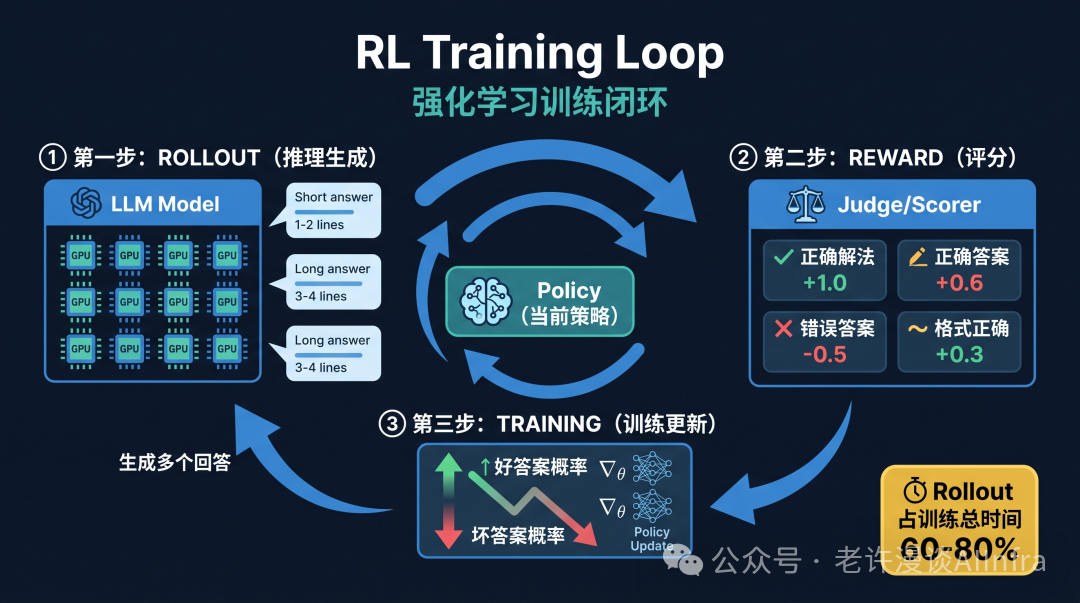

In [3]:
Image(filename='./Image/rl_02.png')

大多数人熟悉的"预训练"是拿大量文本让模型学会预测下一个 Token。强化学习（RL）干的事不一样：它要让模型学会在特定任务上产出更好的结果——比如解数学题、写代码、按人类偏好回答问题。

RL 的核心循环可以理解成三个步骤不断重复：
1. Rollout（推理生成）：用当前版本的模型（Policy）生成一批答案。比如给 1000 道数学题，每题让模型生成多个解法。
2. Reward（评分）：对每个答案打分。数学题可以自动验证是否正确；聊天问答则可能用奖励模型或人工打分。
3. Training（训练更新）：根据 Reward 信号调整模型参数——让高分答案的生成概率上升，低分答案的概率下降。听起来简单。但当模型是 300B 参数的庞然大物，Rollout 要生成 8000 个 Token 的长答案，整个循环每一秒都跑在成百上千张 GPU 上时，每一个环节都会变成一道工程难题。

反直觉事实： RL 训练中，真正的时间杀手往往不是"训练"本身，而是"推理生成"阶段（Rollout）。DeepSeek-R1 论文中的实验数据显示，在某些配置下 Rollout 占据了整个训练时间的 60%–80%。训练节点在等推理节点出结果，推理节点在等长尾样本结束，长尾样本在等模型一个 Token 一个 Token 地解码——时间就这样一层层地浪费掉了。

# RL 的时间为什么耗在推理侧

大模型 RL 的一个反直觉事实是：训练并不一定是最慢的部分。大量时间花在 Rollout，也就是让当前 Policy 生成 Response、调用环境、获得 Reward，再把数据送回训练。长尾样本会拖住整个 Batch。短 Response 已经结束，少数长 Response 仍在逐 Token Decode；同步系统只能等最慢样本结束，才能开始下一轮更新。想象一个 100 人的接力跑：99 个人已经跑完，只有 1 个人还在路上，全队只能站在终点等。这就是同步 Rollout 的代价。

图 1：同步 Rollout 中，1 个长尾样本（~3000 tokens）让其余 7 个已完成的短样本 GPU 全程空转等待。

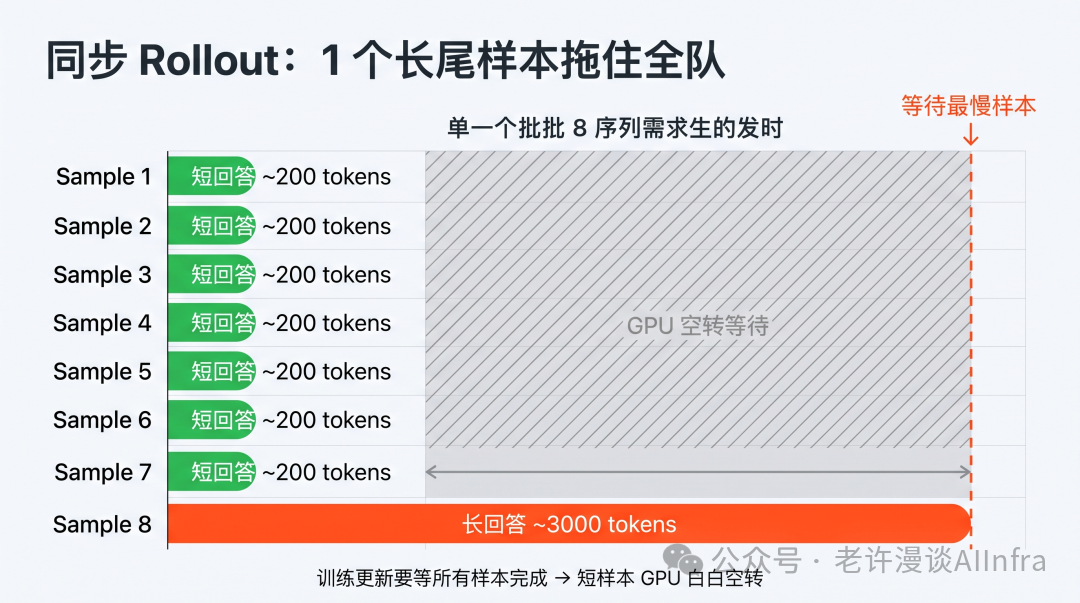

In [4]:
Image(filename='./Image/rl_03.png')

RL 系统要同时处理模型接入、资源管理、参数传输和 Agent Control，典型架构可以分成七层：上层框架（PyTorch/Ray）、通信层（NCCL/Gloo）、训练后端（FSDP 系列）、算法层（PPO/GRPO）、推理引擎（vLLM/SGLang）、权重同步层和模型层。

任何一层的接口不稳定，都会让新模型接入变成一次全栈改造。以 veRL 为代表的开源框架，方向是把训练、推理、权重转换和数据传输"引擎化"，通过接口按需装配，让上层算法研究者不需要关心底层拼接逻辑。

# FSDP Turbo 如何压长序列成本